<a href="https://www.kaggle.com/code/sonawanelalitsunil/remote-work-health-survey-june-2025-ml?scriptVersionId=248474350" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/remote-work-health-impact-survey-2025/post_pandemic_remote_work_health_impact_2025.csv


## Title:
Remote Work Health Survey – June 2025

## Detailed Description:
This survey aims to assess the physical, mental, and social health impacts of remote work as experienced in June 2025. It gathers insights from professionals across various industries to understand how working from home affects daily routines, stress levels, productivity, work-life balance, and overall well-being. The results will help organizations and policymakers make informed decisions to support healthier remote work environments.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/remote-work-health-impact-survey-2025/post_pandemic_remote_work_health_impact_2025.csv')

In [3]:
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


In [4]:
df.tail()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
3152,2025-06-26,62,Female,South America,Professional Services,Data Analyst,Hybrid,38,PTSD,Medium,4,Shoulder Pain; Neck Pain,3,$80K-100K
3153,2025-06-26,24,Female,South America,Professional Services,Software Engineer,Remote,54,NaN,Medium,4,Eye Strain,4,$100K-120K
3154,2025-06-26,45,Female,North America,Professional Services,HR Manager,Onsite,59,PTSD,Medium,1,Shoulder Pain,3,$40K-60K
3155,2025-06-26,38,Male,North America,Education,Operations Manager,Onsite,52,Depression,Medium,3,Shoulder Pain; Eye Strain; Neck Pain,5,$80K-100K
3156,2025-06-26,54,Female,North America,Healthcare,Technical Writer,Onsite,39,Burnout,Medium,4,Back Pain; Eye Strain,2,$100K-120K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Survey_Date              3157 non-null   object
 1   Age                      3157 non-null   int64 
 2   Gender                   3157 non-null   object
 3   Region                   3157 non-null   object
 4   Industry                 3157 non-null   object
 5   Job_Role                 3157 non-null   object
 6   Work_Arrangement         3157 non-null   object
 7   Hours_Per_Week           3157 non-null   int64 
 8   Mental_Health_Status     2358 non-null   object
 9   Burnout_Level            3157 non-null   object
 10  Work_Life_Balance_Score  3157 non-null   int64 
 11  Physical_Health_Issues   2877 non-null   object
 12  Social_Isolation_Score   3157 non-null   int64 
 13  Salary_Range             3157 non-null   object
dtypes: int64(4), object(10)
memory usage: 34

In [6]:
df.describe()

,Age,Hours_Per_Week,Work_Life_Balance_Score,Social_Isolation_Score
count,3157.000000,3157.000000,3157.000000,3157.000000
mean,43.732024,49.904973,2.996516,2.704783
std,12.661095,8.897699,1.163307,1.188887
min,22.000000,35.000000,1.000000,1.000000
25%,33.000000,42.000000,2.000000,2.000000
50%,44.000000,50.000000,3.000000,3.000000
75%,55.000000,57.000000,4.000000,4.000000
max,65.000000,65.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

Survey_Date                  0
Age                          0
Gender                       0
Region                       0
Industry                     0
Job_Role                     0
Work_Arrangement             0
Hours_Per_Week               0
Mental_Health_Status       799
Burnout_Level                0
Work_Life_Balance_Score      0
Physical_Health_Issues     280
Social_Isolation_Score       0
Salary_Range                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Survey_Date                object
Age                         int64
Gender                     object
Region                     object
Industry                   object
Job_Role                   object
Work_Arrangement           object
Hours_Per_Week              int64
Mental_Health_Status       object
Burnout_Level              object
Work_Life_Balance_Score     int64
Physical_Health_Issues     object
Social_Isolation_Score      int64
Salary_Range               object
dtype: object

In [10]:
df.shape

(3157, 14)

In [11]:
df.columns

Index(['Survey_Date', 'Age', 'Gender', 'Region', 'Industry', 'Job_Role',
       'Work_Arrangement', 'Hours_Per_Week', 'Mental_Health_Status',
       'Burnout_Level', 'Work_Life_Balance_Score', 'Physical_Health_Issues',
       'Social_Isolation_Score', 'Salary_Range'],
      dtype='object')

## Data visualizations

In [12]:
print(df.info())
print(df.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Survey_Date              3157 non-null   object
 1   Age                      3157 non-null   int64 
 2   Gender                   3157 non-null   object
 3   Region                   3157 non-null   object
 4   Industry                 3157 non-null   object
 5   Job_Role                 3157 non-null   object
 6   Work_Arrangement         3157 non-null   object
 7   Hours_Per_Week           3157 non-null   int64 
 8   Mental_Health_Status     2358 non-null   object
 9   Burnout_Level            3157 non-null   object
 10  Work_Life_Balance_Score  3157 non-null   int64 
 11  Physical_Health_Issues   2877 non-null   object
 12  Social_Isolation_Score   3157 non-null   int64 
 13  Salary_Range             3157 non-null   object
dtypes: int64(4), object(10)
memory usage: 34

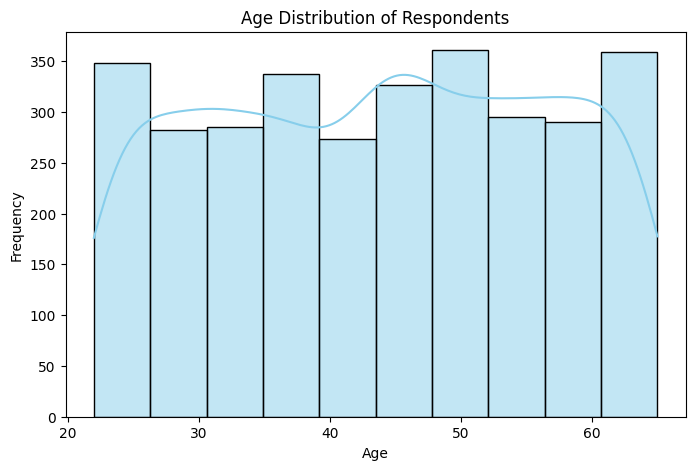

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


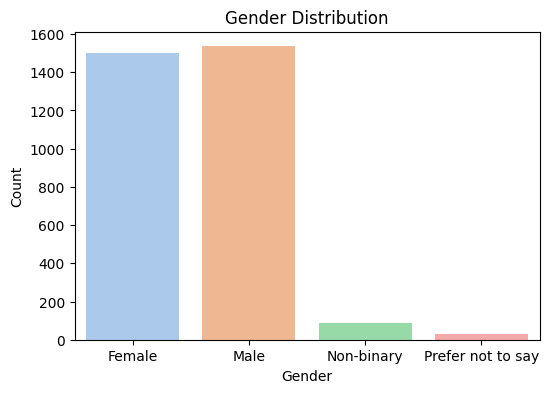

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


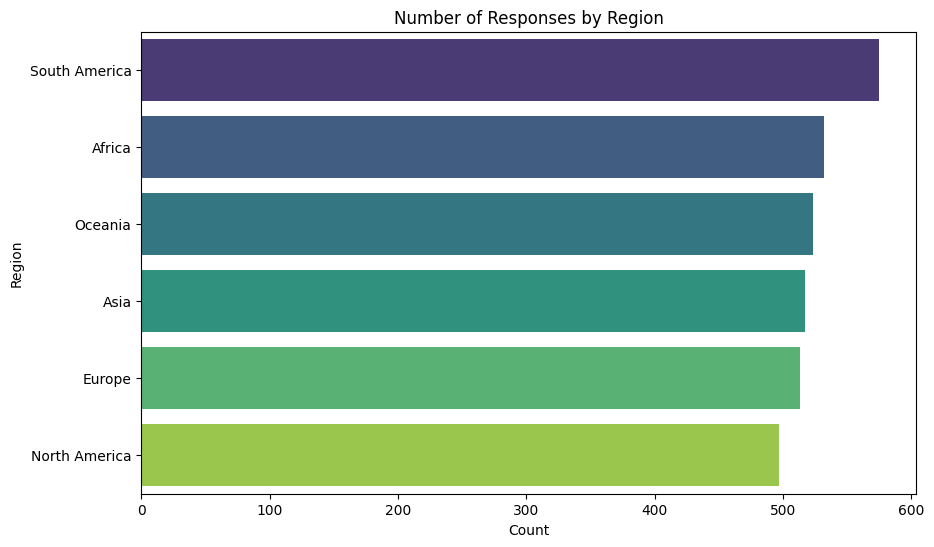

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Region', order=df['Region'].value_counts().index, palette='viridis')
plt.title('Number of Responses by Region')
plt.xlabel('Count')
plt.ylabel('Region')
plt.show()


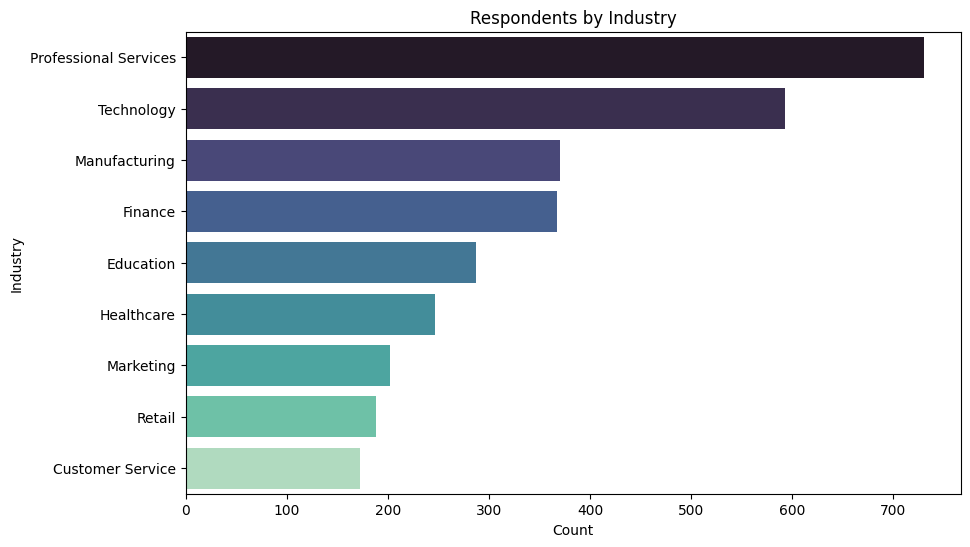

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Industry', order=df['Industry'].value_counts().index, palette='mako')
plt.title('Respondents by Industry')
plt.xlabel('Count')
plt.ylabel('Industry')
plt.show()


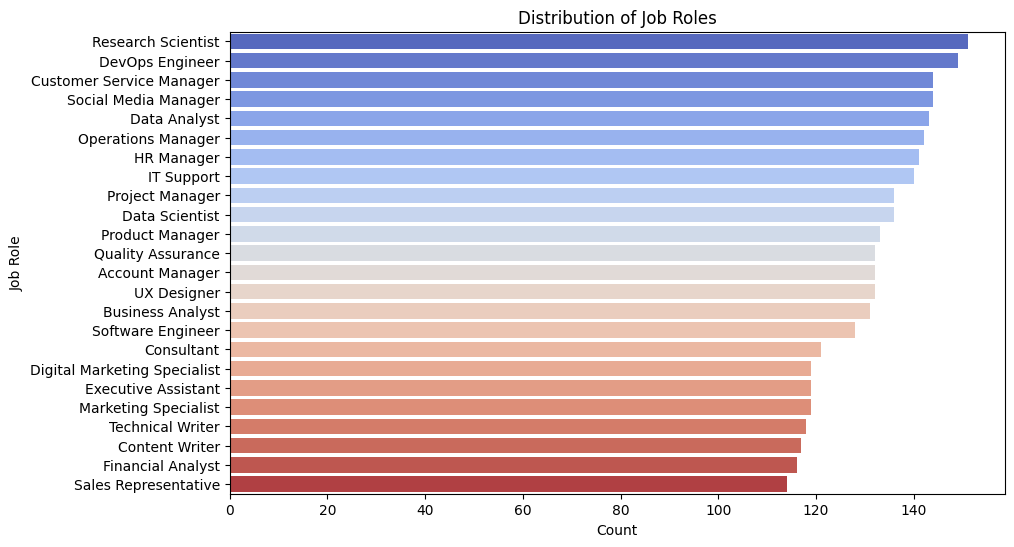

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Job_Role', order=df['Job_Role'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Job Roles')
plt.xlabel('Count')
plt.ylabel('Job Role')
plt.show()


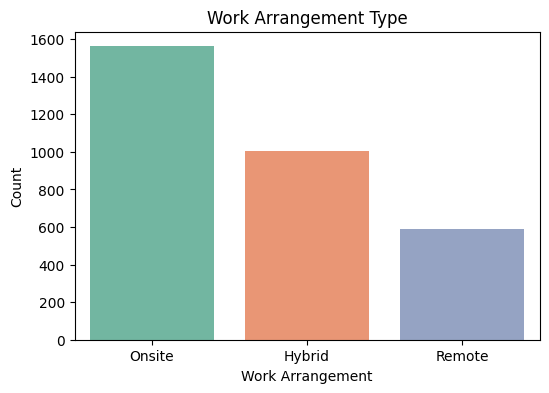

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Work_Arrangement', palette='Set2')
plt.title('Work Arrangement Type')
plt.xlabel('Work Arrangement')
plt.ylabel('Count')
plt.show()


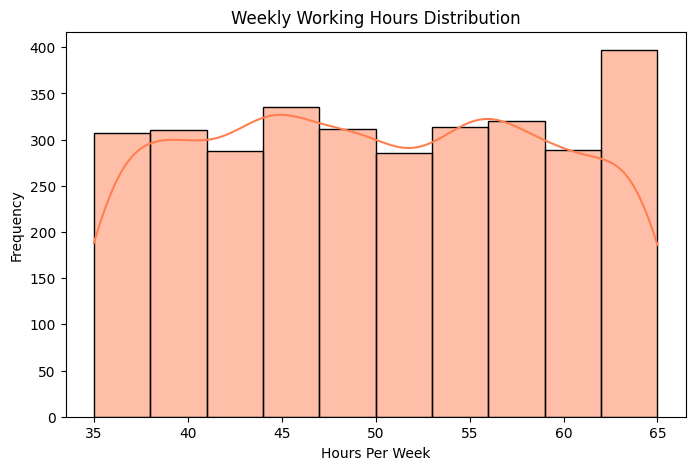

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Hours_Per_Week'], bins=10, kde=True, color='coral')
plt.title('Weekly Working Hours Distribution')
plt.xlabel('Hours Per Week')
plt.ylabel('Frequency')
plt.show()


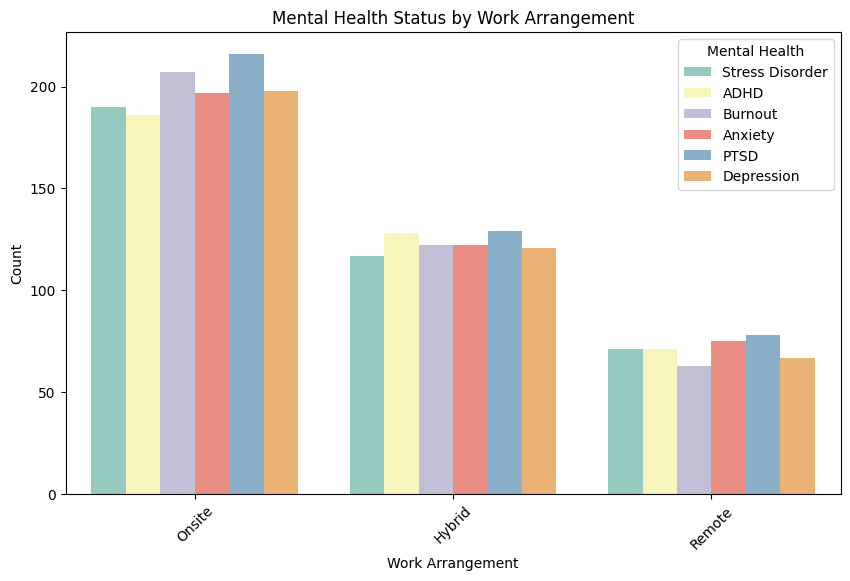

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Work_Arrangement', hue='Mental_Health_Status', palette='Set3')
plt.title('Mental Health Status by Work Arrangement')
plt.xlabel('Work Arrangement')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Mental Health')
plt.show()


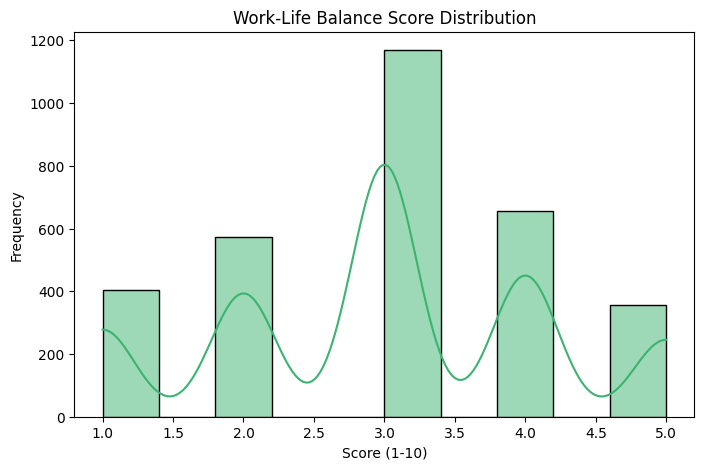

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Work_Life_Balance_Score'], bins=10, kde=True, color='mediumseagreen')
plt.title('Work-Life Balance Score Distribution')
plt.xlabel('Score (1-10)')
plt.ylabel('Frequency')
plt.show()


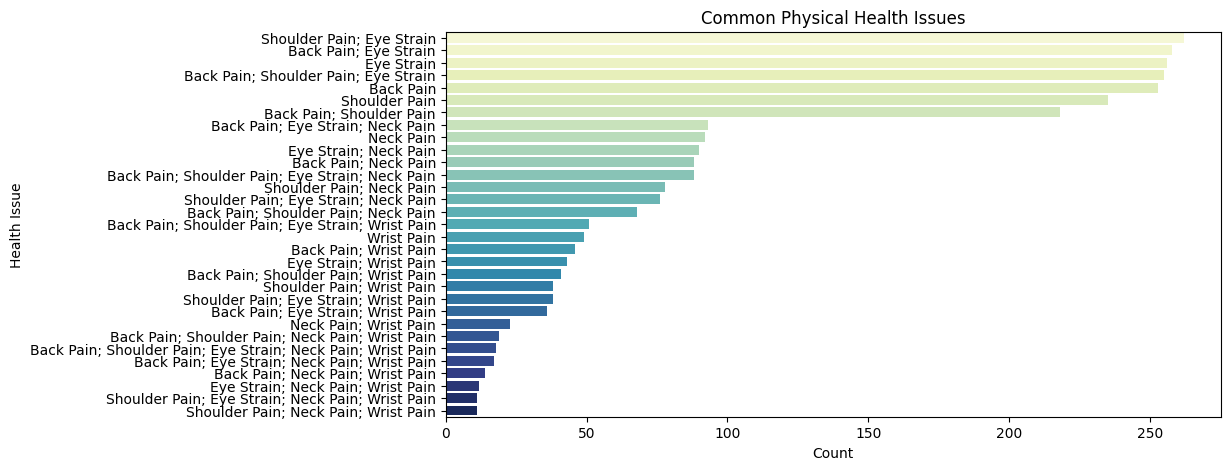

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Physical_Health_Issues', order=df['Physical_Health_Issues'].value_counts().index, palette='YlGnBu')
plt.title('Common Physical Health Issues')
plt.xlabel('Count')
plt.ylabel('Health Issue')
plt.show()


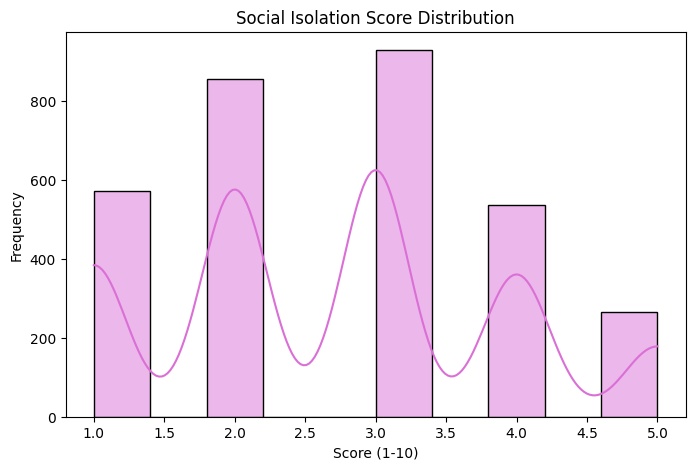

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Social_Isolation_Score'], bins=10, kde=True, color='orchid')
plt.title('Social Isolation Score Distribution')
plt.xlabel('Score (1-10)')
plt.ylabel('Frequency')
plt.show()


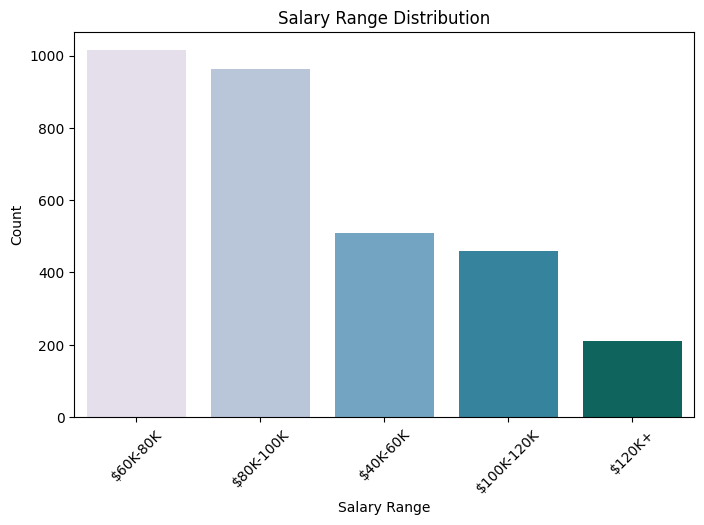

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Salary_Range', order=df['Salary_Range'].value_counts().index, palette='PuBuGn')
plt.title('Salary Range Distribution')
plt.xlabel('Salary Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


## Predictive modeling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [26]:
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

In [27]:
X = df.drop(columns=['Mental_Health_Status'])  # Change target column if needed
y = df['Mental_Health_Status']


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

In [30]:
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies[name] = round(acc * 100, 2)


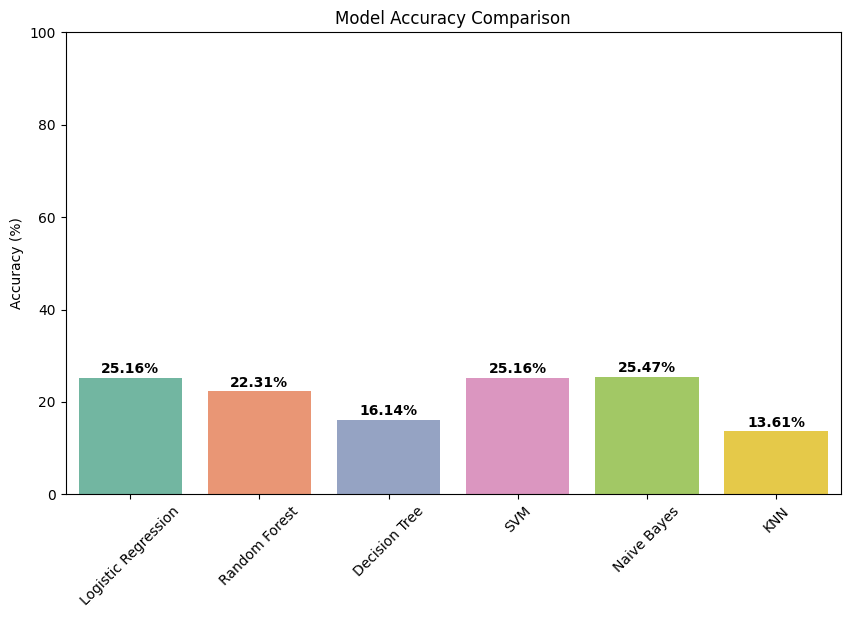

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='Set2')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')
plt.ylim(0, 100)
plt.show()

In [32]:
for name, acc in accuracies.items():
    print(f"{name}: {acc}% accuracy")

Logistic Regression: 25.16% accuracy
Random Forest: 22.31% accuracy
Decision Tree: 16.14% accuracy
SVM: 25.16% accuracy
Naive Bayes: 25.47% accuracy
KNN: 13.61% accuracy


## Thank you pls upvote!!!